In [7]:
import sys
import os
sys.path.append(os.path.abspath("../"))  # or "../../" depending on location

In [8]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from utils.formate_matrix_toMLData import *
from models.model_bayes_1122 import *
import matplotlib.pyplot as plt
from tqdm import tqdm
import japanize_matplotlib
plt.rcParams["font.size"] = 22
np.set_printoptions(suppress=True)
import seaborn as sns

In [9]:
formater = formate_dataMatrix()

# 読み込む対象の拡張子（例: .csv のみに限定）
VALID_EXTENSIONS = (".csv", ".txt")
IGNORED_PREFIXES = ("._", ".DS_Store", "Thumbs.db")

# ファイルを処理する関数
def process_file(file_path, states_sets, delt_sets, true_sets,targets_sets,ll_use):
    try:
        print("Processing:", file_path)
        with open(file_path, 'rb') as f:
            all_matrix = np.loadtxt(f, delimiter=",")

        tm = matrix_trimer(all_matrix)
        true_trm = tm.trim_transitionRateMatrix(start = 0, end = 4)
        true_vec = np.array(formater.GetOutputVector_byDiagonal(true_trm))
        data = []
        if ll_use:
            
            ll_trm = tm.trim_transitionRateMatrix(start = 4, end = 8)
            ll_vec = np.array(formater.GetOutputVector_byDiagonal(ll_trm))
            data = tm.trim_data(start = 8)
        else:
            data = tm.trim_data(start = 4)
            ll_vec = np.array([0,0,0])
            
        print(data)
        # state: shape (2, num_samples_i)
        state = np.stack([data[:, 0], data[:, 1]], axis=0)
        states_sets.append(state)
        delt_sets.append(data[:, 2])
        true_sets.append(true_vec)
        targets_sets.append(ll_vec)

    except Exception as e:
        print(f"❌ Skipping file: {file_path} (Reason: {e})")

# ディレクトリ内のファイルを一括処理
def process_all_files_in_directory(directory, func, states_sets, delt_sets, true_sets,targets_sets,ll_use = True):
    for filename in os.listdir(directory):
        if filename.startswith(IGNORED_PREFIXES):
            continue
        if not filename.endswith(VALID_EXTENSIONS):
            continue

        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path):
            func(file_path,states_sets, delt_sets, true_sets,targets_sets,ll_use)

test_states = []
test_del_t = []
test_targets = []
dummy = []
# data_dir = "/media/user/TRANSCEND/datas/discrete_test"
data_dir = "/Volumes/TRANSCEND/datas/discrete_test"
# 実行
process_all_files_in_directory(data_dir,process_file, test_states, test_del_t,test_targets,dummy,False)
test_dataset = varSets_Datasets(test_states, test_del_t, test_targets)
use_cuda = torch.cuda.is_available()
test_dataloader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=use_cuda,
)


Processing: /Volumes/TRANSCEND/datas/discrete_test/11_10000_4.csv
[[ 2.   3.  62.9]
 [ 2.   4.  90.6]
 [ 2.   4.  90.6]
 ...
 [ 2.   4.  62.9]
 [ 2.   4.  62.9]
 [ 2.   4.  62.9]]
Processing: /Volumes/TRANSCEND/datas/discrete_test/8_10000_4.csv
[[ 2.   3.  60.8]
 [ 2.   3.   8.2]
 [ 1.   3.  95.2]
 ...
 [ 2.   3.  25.8]
 [ 2.   3.  60.8]
 [ 1.   3.  95.2]]
Processing: /Volumes/TRANSCEND/datas/discrete_test/15_10000_4.csv
[[ 3.   3.  16.6]
 [ 3.   3.  16.6]
 [ 3.   4.  84.3]
 ...
 [ 3.   4.  66.4]
 [ 1.   4.  37.9]
 [ 3.   4.  37.2]]
Processing: /Volumes/TRANSCEND/datas/discrete_test/20_10000_4.csv
[[ 2.   3.  74.1]
 [ 1.   2.  11.7]
 [ 3.   4.  74.1]
 ...
 [ 2.   4.  74.1]
 [ 2.   2.  74.1]
 [ 2.   2.  74.1]]
Processing: /Volumes/TRANSCEND/datas/discrete_test/17_10000_4.csv
[[ 3.   4.  71. ]
 [ 3.   4.  66.3]
 [ 3.   3.  17. ]
 ...
 [ 2.   3.  71. ]
 [ 3.   4.  94.4]
 [ 3.   4.  59. ]]
Processing: /Volumes/TRANSCEND/datas/discrete_test/4_10000_4.csv
[[ 1.   1.   1.3]
 [ 1.   2.  18.6]


In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = DeepSets_varSets_forDiagnel(device=device)
model.load_state_dict(torch.load("../model_weights/mixed_distribution/mixed_bayes_1122.pth", map_location=device))
model.eval()

def evaluate_nll(model, val_loader):
    """平均 Negative Log-Likelihood を計算"""
    model.eval()
    total_logp = 0.0
    count = 0

    with torch.no_grad():
        for state, delta_t, q_true, lengths in tqdm(val_loader, desc="Eval NLL"):
            logp = model.log_prob(state, delta_t, lengths, q_true)  # (B,)
            total_logp += logp.sum().item()
            count += state.size(0)

    avg_nll = - total_logp / max(count, 1)
    return avg_nll

def evaluate_rmse(model, val_loader):
    """事後平均（forward 出力）と真値の RMSE"""
    model.eval()
    total_rmse = 0.0
    count = 0

    with torch.no_grad():
        for state, delta_t, q_true, lengths in tqdm(val_loader, desc="Eval RMSE"):
            state = state.to(model.device)
            delta_t = delta_t.to(model.device)
            q_true = q_true.to(model.device)
            lengths = lengths.to(model.device)

            q_pred = model(state, delta_t, lengths)  # (B,3)
            mse = ((q_pred - q_true)**2).sum(dim=1).sqrt()  # L2 norm per sample
            total_rmse += mse.sum().item()
            count += state.size(0)

def evaluate_credible_interval(
    model,
    val_loader,
    num_samples: int = 2000,
    cred: float = 0.95,
):
    """95% credible interval coverage を評価"""
    model.eval()
    device = model.device
    alpha = (1 - cred) / 2.0   # 0.025 (95% CI)

    total = 0
    covered_all_dims = 0
    covered_any_dim = 0

    for state, delta_t, q_true, lengths in tqdm(val_loader, desc=f"Eval {int(cred*100)}% CI"):
        state = state.to(device)
        delta_t = delta_t.to(device)
        q_true = q_true.to(device)
        lengths = lengths.to(device)

        # posterior sample: (num_samples, B, 3)
        samples = model.sample_posterior(
            state, delta_t, lengths, num_samples=num_samples
        )[:, 0, :]   # (S,3)  B=1 前提

        # 各次元ごとに CI を計算
        q_low = torch.quantile(samples, alpha, dim=0)      # (3,)
        q_high = torch.quantile(samples, 1-alpha, dim=0)   # (3,)

        inside = torch.logical_and(q_true[0] >= q_low, q_true[0] <= q_high)  # (3,)

        if inside.all():
            covered_all_dims += 1
        if inside.any():
            covered_any_dim += 1

        total += 1

    coverage_all = covered_all_dims / max(total, 1)
    coverage_any = covered_any_dim / max(total, 1)
    print(f"{int(cred*100)}% CI coverage (all 3 dims inside): {coverage_all:.4f}")
    print(f"{int(cred*100)}% CI coverage (any dim inside)  : {coverage_any:.4f}")
    return coverage_all, coverage_any

def visualize_posterior(
    model,
    sample_state,
    sample_delta_t,
    sample_lengths,
    q_true,
    num_samples=2000,
    figsize=(8, 10),
    bins=80
):
    """
    q12, q23, q34 の 1 次元 posterior 分布（ヒスト + KDE）を描画する。
    """
    model.eval()
    device = model.device

    # to device
    sample_state = sample_state.to(device)
    sample_delta_t = sample_delta_t.to(device)
    sample_lengths = sample_lengths.to(device)
    q_true = q_true.to(device)

    # posterior samples
    with torch.no_grad():
        samples = model.sample_posterior(
            sample_state,
            sample_delta_t,
            sample_lengths,
            num_samples=num_samples,
        )[:, 0, :]  # (S, 3)

    samples = samples.cpu().numpy()
    true_vals = q_true[0].detach().cpu().numpy()

    dims = ["q12", "q23", "q34"]

    plt.figure(figsize=figsize)
    for i, dim in enumerate(dims):
        plt.subplot(3, 1, i + 1)

        # KDE + ヒスト
        sns.histplot(samples[:, i], bins=bins, kde=True, stat="density", color="skyblue")

        # 真値
        plt.axvline(true_vals[i], color="red", linestyle="--", linewidth=2)

        plt.title(f"Posterior of {dim} (True={true_vals[i]:.4f})")
        plt.xlabel(dim)
        plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

def visualize_inverse_posterior(
    model,
    sample_state,
    sample_delta_t,
    sample_lengths,
    q_true,
    num_samples=2000,
    figsize=(8, 10),
    bins=80
):
    """
    q12, q23, q34 の逆数 (1/q) の 1 次元 posterior 分布を描画する。
    1/q = 平均滞在時間（寿命）なので、寿命分布の可視化として有用。
    """
    model.eval()
    device = model.device

    # to device
    sample_state = sample_state.to(device)
    sample_delta_t = sample_delta_t.to(device)
    sample_lengths = sample_lengths.to(device)
    q_true = q_true.to(device)

    # posterior samples: (S, 3)
    with torch.no_grad():
        samples = model.sample_posterior(
            sample_state,
            sample_delta_t,
            sample_lengths,
            num_samples=num_samples,
        )[:, 0, :]

    samples = samples.cpu().numpy()
    inv_samples = 1.0 / samples   # ← 逆数を取るだけでOK

    true_vals = q_true[0].detach().cpu().numpy()
    inv_true = 1.0 / true_vals

    dims = ["1/q12", "1/q23", "1/q34"]

    plt.figure(figsize=figsize)
    for i, dim in enumerate(dims):
        plt.subplot(3, 1, i + 1)

        sns.histplot(inv_samples[:, i], bins=bins, kde=True, stat="density", color="lightgreen")
        plt.axvline(inv_true[i], color="red", linestyle="--", linewidth=2)

        plt.title(f"Posterior of {dim} (True={inv_true[i]:.4f})")
        plt.xlabel(dim)
        plt.ylabel("Density")

    plt.tight_layout()
    plt.show()



/var/folders/k3/b1t1gjg12pg0ycfdgpm2k7g00000gn/T/ipykernel_58744/1225547076.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../model_we

True q: tensor([[0.0223, 0.0304, 0.0209]])


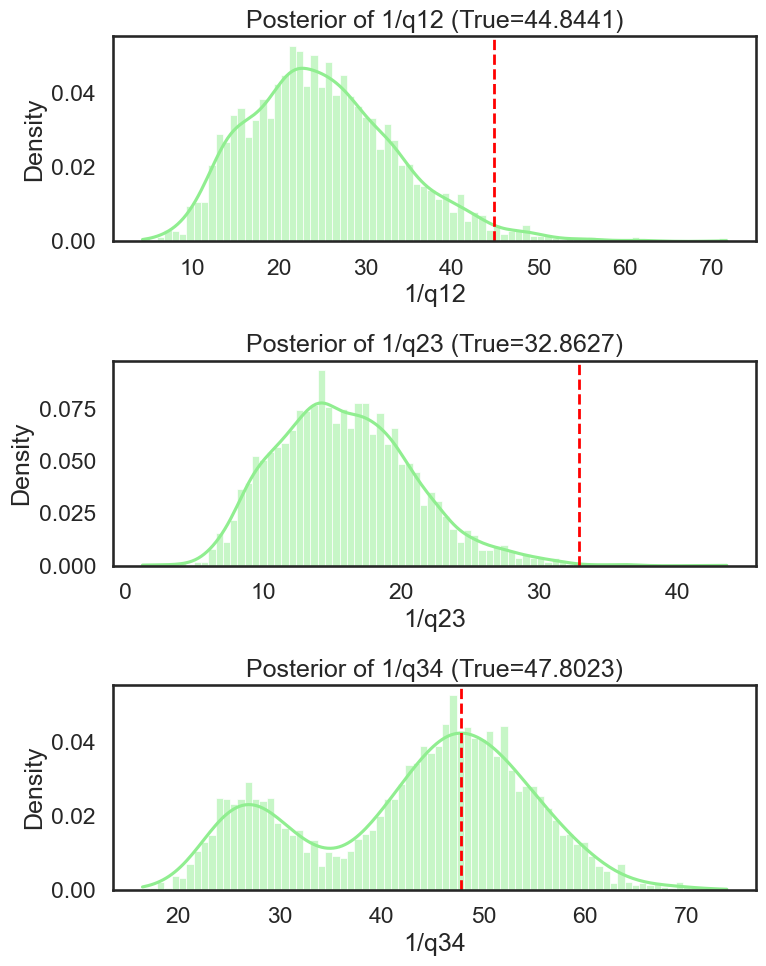

In [20]:
# 可視化したいサンプルのインデックス
sample_idx = 140

# DataLoader の順番を固定している前提（shuffle=False）
state_all, delta_t_all, q_true_all, lengths_all = next(iter(DataLoader(
    test_dataset,
    batch_size=len(test_dataset),
    shuffle=False,
    collate_fn=collate_fn,
)))

sample_state = state_all[sample_idx:sample_idx+1]
sample_delta_t = delta_t_all[sample_idx:sample_idx+1]
sample_q_true = q_true_all[sample_idx:sample_idx+1]
sample_lengths = lengths_all[sample_idx:sample_idx+1]

print("True q:", sample_q_true)

visualize_inverse_posterior(
    model,
    sample_state,
    sample_delta_t,
    sample_lengths,
    sample_q_true,
    num_samples=3000,
)